In [1]:
# fnirs_preprocessing.py
# 2/26/2025 - 3/10/2025
# Mady Davis-Troller
# to learn how to do fnirs preprocessing 
#################################

# 1 import packages
# 2 load in data 
# 3 visualize time courses, sensors
# 4 convert intensity to optical density
# 5 check scalp coupling index (SCI), mark bad channels
# 6 apply TDDR (temporal derivative distribution repair), remove movement artifact
# 7 high-pass filter the data, low cut off of .01Hz
# 8 apply short channel regression/enhancement
# 9 low-pass filter the data
# 10 apply the MBLL modified beer lambert law, units of change in micromolar

#################################

# https://mne.tools/1.8/auto_tutorials/preprocessing/70_fnirs_processing.html

In [2]:
# 1 import packages
%matplotlib inline

from itertools import compress

import os
import matplotlib.pyplot as plt
import numpy as np

import mne
import mne_nirs

In [3]:
# 2 load in data 
# fnirs_data_folder = mne.datasets.fnirs_motor.data_path()
# fnirs_cw_amplitude_dir = fnirs_data_folder / "Participant-1"
# raw_intensity = mne.io.read_raw_nirx(fnirs_cw_amplitude_dir, verbose=True)
os.chdir("C:/Users/piano/Box/Lab Manager/ILLL/FNIRS/data")
raw_intensity = mne.io.read_raw_snirf("2025-04-01_001.snirf")
raw_intensity.load_data()

Loading C:\Users\piano\Box\Lab Manager\ILLL\FNIRS\data\2025-04-01_001.snirf
Reading 0 ... 4531  =      0.000 ...   445.397 secs...


<RawSNIRF | 2025-04-01_001.snirf, 50 x 4532 (445.5 s), ~1.9 MiB, data loaded>

In [4]:
#annotations for markers 
raw_intensity.annotations.set_durations(5)
raw_intensity.annotations.rename(
    {"1": "Start", "2": "End"} 
)
unwanted = np.nonzero(raw_intensity.annotations.description == "15.0")
raw_intensity.annotations.delete(unwanted)

In [6]:
# 3 visualize time courses, sensors

#for viewing data of brain sensors overlaid on head

subjects_dir = mne.datasets.sample.data_path() / "subjects" # CHANGE THIS
#subjects_dir = "C:/Users/piano/Box/Lab Manager/ILLL/FNIRS/data"
#will be set to our subject directory

brain = mne.viz.Brain(
    "fsaverage", subjects_dir=subjects_dir, background="w", cortex="0.5"
)
brain.add_sensors(
    raw_intensity.info,
    trans="fsaverage",
    fnirs=["channels", "pairs", "sources", "detectors"],
)
brain.show_view(azimuth=20, elevation=60, distance=400)

False
Channel types::	fnirs_cw_amplitude: 50


C:\Users\piano\AppData\Local\Temp\ipykernel_35212\439110771.py:12: RuntimeWarning: Got coordinate frame "unknown" for ['S1_D1 760', 'S1_D1 760', 'S1_D1 760', 'S1_D2 760', 'S1_D2 760', 'S1_D2 760', 'S1_D8 760', 'S1_D8 760', 'S1_D8 760', 'S2_D1 760', 'S2_D1 760', 'S2_D1 760', 'S2_D2 760', 'S2_D2 760', 'S2_D2 760', 'S2_D9 760', 'S2_D9 760', 'S2_D9 760', 'S3_D2 760', 'S3_D2 760', 'S3_D2 760', 'S3_D3 760', 'S3_D3 760', 'S3_D3 760', 'S3_D10 760', 'S3_D10 760', 'S3_D10 760', 'S4_D3 760', 'S4_D3 760', 'S4_D3 760', 'S4_D4 760', 'S4_D4 760', 'S4_D4 760', 'S4_D11 760', 'S4_D11 760', 'S4_D11 760', 'S5_D4 760', 'S5_D4 760', 'S5_D4 760', 'S5_D5 760', 'S5_D5 760', 'S5_D5 760', 'S5_D12 760', 'S5_D12 760', 'S5_D12 760', 'S6_D4 760', 'S6_D4 760', 'S6_D4 760', 'S6_D5 760', 'S6_D5 760', 'S6_D5 760', 'S6_D13 760', 'S6_D13 760', 'S6_D13 760', 'S7_D5 760', 'S7_D5 760', 'S7_D5 760', 'S7_D6 760', 'S7_D6 760', 'S7_D6 760', 'S7_D7 760', 'S7_D7 760', 'S7_D7 760', 'S7_D14 760', 'S7_D14 760', 'S7_D14 760', 'S8_D5 7

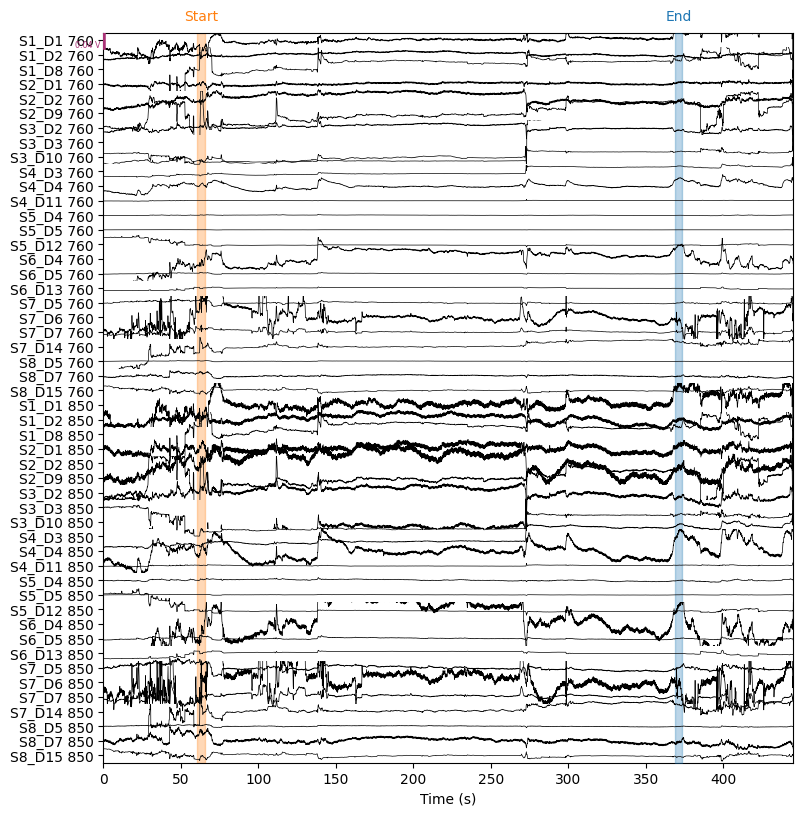

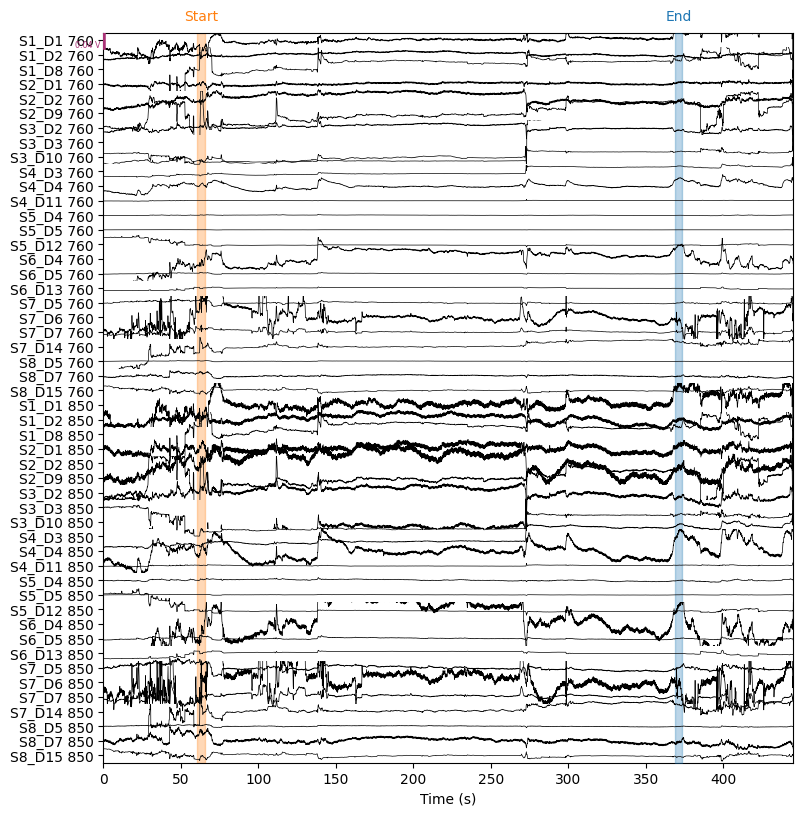

In [8]:
# 4 convert intensity to optical density

#find changes in deoxy and oxy blood
#modified Beer Lambert Law

picks = mne.pick_types(raw_intensity.info, meg=False, fnirs=True)
dists = mne.preprocessing.nirs.source_detector_distances(
    raw_intensity.info, picks=picks
)
#raw_intensity.pick(picks[dists > 0.01]) #the line is get long channels essentially
raw_intensity.plot(
    n_channels=len(raw_intensity.ch_names), duration=500, show_scrollbars=False
)

In [9]:
# 4 convert intensity to optical density 
raw_od = mne.preprocessing.nirs.optical_density(raw_intensity)
#raw_od.plot(n_channels=len(raw_od.ch_names), duration=500, show_scrollbars=False)

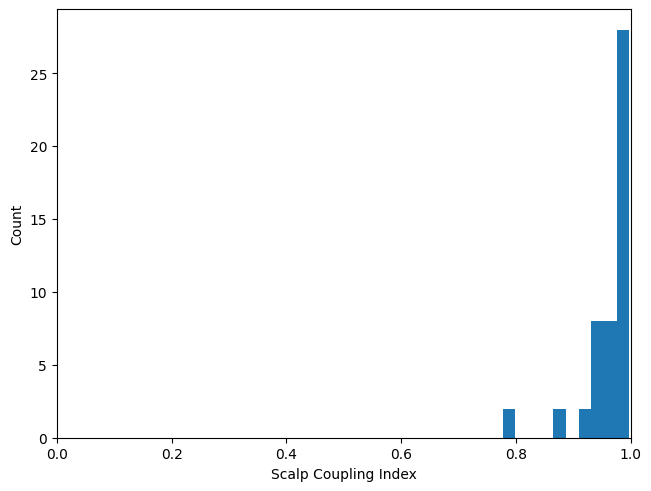

In [11]:
# 5 check scalp coupling index (SCI), mark bad channels
#check data at channel level, SCI at .8 or higher
sci = mne.preprocessing.nirs.scalp_coupling_index(raw_od)
fig, ax = plt.subplots(layout="constrained")
ax.hist(sci)
ax.set(xlabel="Scalp Coupling Index", ylabel="Count", xlim=[0, 1])
raw_od.info["bads"] = list(compress(raw_od.ch_names, sci < 0.5)) # will set threshold for what data is considered bad

In [12]:
# 6 applied TDDR
raw_tddr = mne.preprocessing.nirs.temporal_derivative_distribution_repair(raw_od.copy(), verbose=None)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.01 Hz

IIR filter parameters
---------------------
Butterworth highpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 0.01 Hz: -6.02 dB

Effective window size : 201.318 (s)
Plotting power spectral density (dB=True).
Effective window size : 201.318 (s)
Plotting power spectral density (dB=True).


C:\Users\piano\AppData\Local\Programs\Python\Python311\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
C:\Users\piano\AppData\Local\Programs\Python\Python311\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


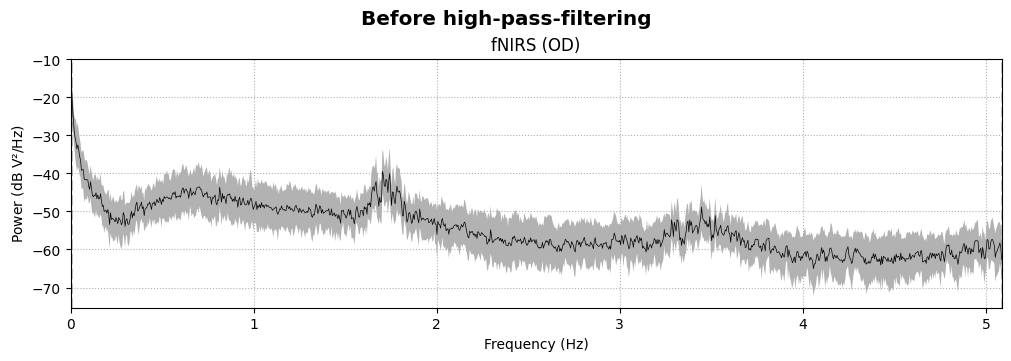

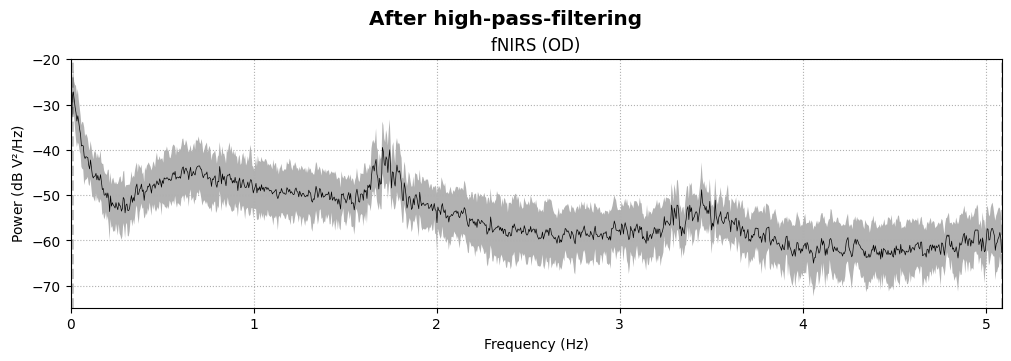

In [13]:
# 7 high pass filter the data, keep high frq info and reject low frq info by defining boundaries

raw_od_unfiltered = raw_tddr.copy()
raw_od_hfiltered = raw_tddr.copy()
raw_od_hfiltered.filter(l_freq = 0.01, h_freq = None, h_trans_bandwidth = None, l_trans_bandwidth = 0.01/2, 
                         method = 'iir', phase = 'zero') #band pass filter, need to decide filter cutoffs (0.01, 0.3), iir is a filter for time series
for when, _raw in dict(Before=raw_od_unfiltered, After=raw_od_hfiltered).items():
    fig = _raw.compute_psd().plot(
        average=True, amplitude=False, picks="data", exclude="bads"
    )
    fig.suptitle(f"{when} high-pass-filtering", weight="bold", size="x-large")

In [14]:
# 8 short channel regression

raw_od_short = mne_nirs.signal_enhancement.short_channel_regression(raw_od_hfiltered, max_dist=0.01)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.01 Hz

IIR filter parameters
---------------------
Butterworth highpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 0.01 Hz: -6.02 dB

Effective window size : 201.318 (s)
Plotting power spectral density (dB=True).
Effective window size : 201.318 (s)
Plotting power spectral density (dB=True).


C:\Users\piano\AppData\Local\Programs\Python\Python311\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
C:\Users\piano\AppData\Local\Programs\Python\Python311\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


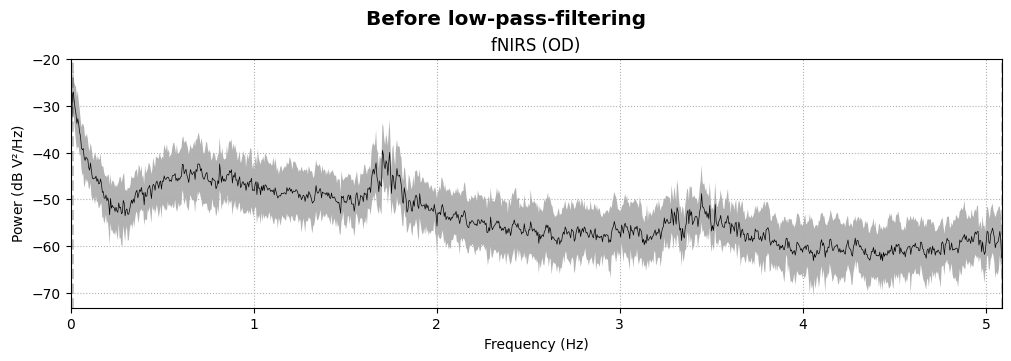

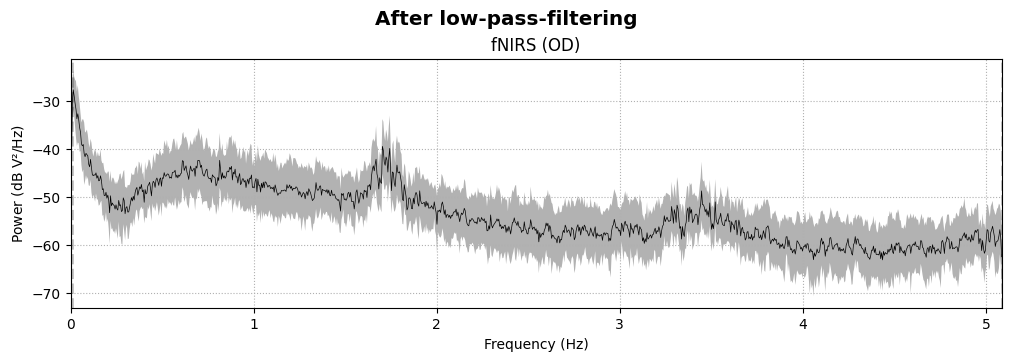

In [15]:
# 9 low pass filters
raw_od_bpfiltered = raw_od_short.copy() #bp = band pass
raw_od_bpfiltered.filter(l_freq = 0.01, h_freq = None, h_trans_bandwidth = None, l_trans_bandwidth = 0.01/2, 
                         method = 'iir', phase = 'zero') #band pass filter, need to decide filter cutoffs (0.01, 0.3), iir is a filter for time series
for when, _raw in dict(Before=raw_od_short, After=raw_od_bpfiltered).items():
    fig = _raw.compute_psd().plot(
        average=True, amplitude=False, picks="data", exclude="bads"
    )
    fig.suptitle(f"{when} low-pass-filtering", weight="bold", size="x-large")

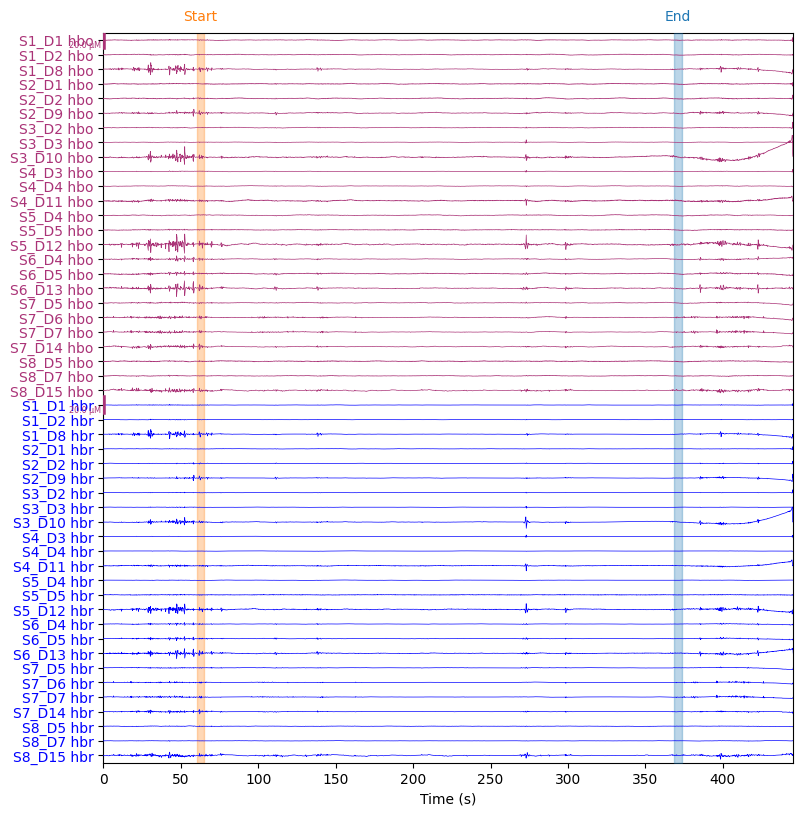

In [34]:
# 10 apply beer_lambert_law and get long/short channels

#raw_haemo = mne.preprocessing.nirs.beer_lambert_law(raw_od, ppf=0.1) #we don't like this ppf (partial pathlength factor)
raw_haemo = mne.preprocessing.nirs.beer_lambert_law(raw_od_bpfiltered.copy()) # this one we do, better representation of the vasculature that we're interested in 
raw_haemo.plot(n_channels=len(raw_haemo.ch_names), duration=500, show_scrollbars=False)

raw_haemo_long = mne_nirs.channels.get_long_channels(raw_haemo.copy())
#raw_haemo_short = mne_nirs.channels.get_short_channels(raw_haemo.copy())

In [41]:
# at the very end we will be in the change in concentration in micromolar 
# data, times = raw_haemo[:]
# print(data)
# print("\n")
# print(len(data[0]))
# print("\n\ntimes:")
# print(times)
# chan = raw_haemo.pick("S1_D1 hbo")
# chan_data, chan_times = chan[:]
# print(chan_data)
raw_haemo_data = raw_haemo_long.copy().pick(picks='hbo')._data

['S1_D1 hbo', 'S1_D2 hbo', 'S2_D1 hbo', 'S2_D2 hbo', 'S3_D2 hbo', 'S3_D3 hbo', 'S4_D3 hbo', 'S4_D4 hbo', 'S5_D4 hbo', 'S5_D5 hbo', 'S6_D4 hbo', 'S6_D5 hbo', 'S7_D5 hbo', 'S7_D6 hbo', 'S7_D7 hbo', 'S8_D5 hbo', 'S8_D7 hbo', 'S1_D1 hbr', 'S1_D2 hbr', 'S2_D1 hbr', 'S2_D2 hbr', 'S3_D2 hbr', 'S3_D3 hbr', 'S4_D3 hbr', 'S4_D4 hbr', 'S5_D4 hbr', 'S5_D5 hbr', 'S6_D4 hbr', 'S6_D5 hbr', 'S7_D5 hbr', 'S7_D6 hbr', 'S7_D7 hbr', 'S8_D5 hbr', 'S8_D7 hbr']
17


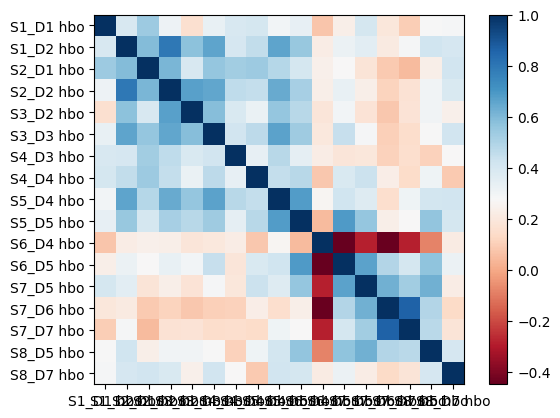

In [60]:
#Functional Connectivity
channel_names = raw_haemo_long.ch_names
print(channel_names)

print(len(raw_haemo_data))

corr_matrix = np.corrcoef(raw_haemo_data)

#plt.imshow(corr_matrix)
#plt.show()
fig, ax = plt.subplots(1,1)
im = ax.imshow(corr_matrix, cmap='RdBu')
ax.set_yticks(np.arange(17))
ax.set_xticks(np.arange(17))
ax.set_xticklabels(channel_names[0:17])
ax.set_yticklabels(channel_names[0:17])
fig.colorbar(im)
plt.show()

In [70]:
raw_hb = raw_haemo_long
picks_hbo = raw_haemo_long.copy().pick(picks='hbo')
channel_names = raw_haemo_long.ch_names[0: 17]

# 3. A computed connectivity matrix, for example from np.corrcoef or epoch-averaging:
# Here, mean_corr_matrix should be a square array with shape (n_channels, n_channels)
# For demonstration, we'll assume mean_corr_matrix is already defined.
# Example (using dummy data):
# mean_corr_matrix = np.random.uniform(low=-1, high=1, size=(len(channel_names), len(channel_names)))
# However, in practice, use your actual connectivity matrix.

n_channels = len(channel_names)

print(picks_hbo)

<RawSNIRF | 2025-04-01_001.snirf, 17 x 4532 (445.5 s), ~732 KiB, data loaded>


[[-0.07833    0.016385 ]
 [-0.071211   0.0342955]
 [-0.0748875  0.028324 ]
 [-0.0677685  0.0462345]
 [-0.0597425  0.059189 ]
 [-0.041864   0.076985 ]
 [-0.0145245  0.0872155]
 [ 0.0146825  0.0872035]
 [ 0.032228   0.082064 ]
 [ 0.049826   0.06467  ]
 [ 0.0416025  0.077121 ]
 [ 0.0592005  0.059727 ]
 [ 0.0672415  0.047069 ]
 [ 0.07135    0.042017 ]
 [ 0.07452    0.029486 ]
 [ 0.0706885  0.0353745]
 [ 0.077967   0.0177915]]
Channel Positions (x, y):
[[-0.07833    0.016385 ]
 [-0.071211   0.0342955]
 [-0.0748875  0.028324 ]
 [-0.0677685  0.0462345]
 [-0.0597425  0.059189 ]
 [-0.041864   0.076985 ]
 [-0.0145245  0.0872155]
 [ 0.0146825  0.0872035]
 [ 0.032228   0.082064 ]
 [ 0.049826   0.06467  ]
 [ 0.0416025  0.077121 ]
 [ 0.0592005  0.059727 ]
 [ 0.0672415  0.047069 ]
 [ 0.07135    0.042017 ]
 [ 0.07452    0.029486 ]
 [ 0.0706885  0.0353745]
 [ 0.077967   0.0177915]]


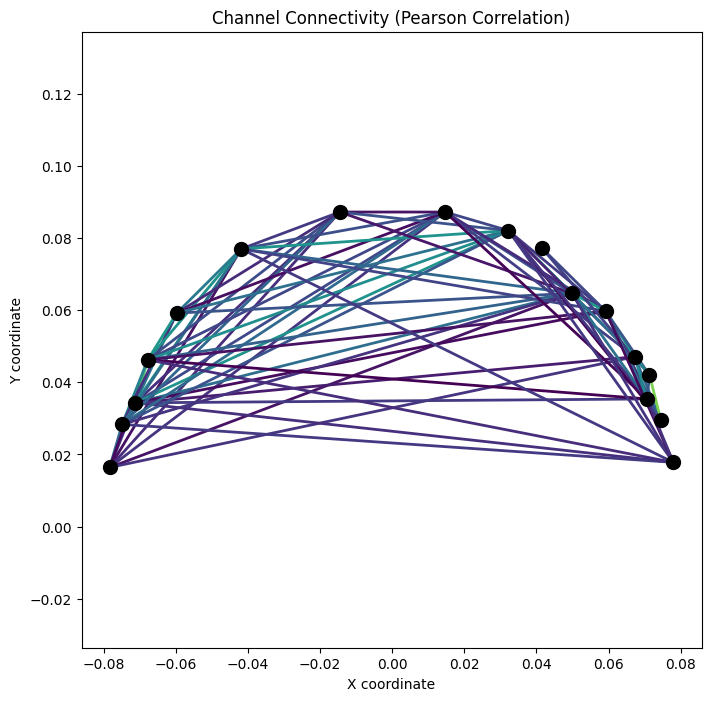

In [72]:


# Extract the 2D positions from the raw.info structure.
# Here, we assume that the first 3 elements of each channel's 'loc' correspond to x, y, z.
# We use x and y for plotting.
channel_positions = []
for name in channel_names:
    idx = raw_hb.info['ch_names'].index(name)
    # Extract the first three coordinates:
    pos = raw_hb.info['chs'][idx]['loc'][:3]
    # Keep only the x and y coordinates; adjust if your montage uses a different order
    channel_positions.append(pos[:2])
channel_positions = np.array(channel_positions)
print(channel_positions)

# Optional: Check if positions are well distributed (print or plot them)
print("Channel Positions (x, y):")
print(channel_positions)

# Plot the connectivity as lines between channels.
# Define a threshold for connectivity strength to display connections.
# You can adjust the threshold as needed.
threshold = 0.3

plt.figure(figsize=(8, 8))
# Plot channel positions as scatter points
plt.scatter(channel_positions[:, 0], channel_positions[:, 1], s=100, color='k', zorder=2)
for i in range(n_channels):
    for j in range(i + 1, n_channels):
        conn_value = corr_matrix[i, j]
        # Optionally, consider absolute value and threshold the connectivity strength
        if np.abs(conn_value) >= threshold:
            # Map the connectivity strength to a color intensity
            # Using a colormap (e.g., viridis) over the interval [threshold, 1]
            color_value = np.clip((np.abs(conn_value) - threshold) / (1 - threshold), 0, 1)
            color = plt.cm.viridis(color_value)
            # Draw a line between channel i and channel j
            plt.plot([channel_positions[i, 0], channel_positions[j, 0]],
                     [channel_positions[i, 1], channel_positions[j, 1]],
                     color=color, lw=2, zorder=1)

plt.title("Channel Connectivity (Pearson Correlation)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.axis('equal')
plt.show()